# Satisfaction Predictors for Business Class Flyers


## Introduction

The airline industry is an interesting paradox: it requires massive capital infrastructure yet operates on razor-thin margins well below most other sectors. While the S&P 500 reported a blended net profit margin of [12.8% in Q3 2025](https://insight.factset.com/sp-500-reporting-net-profit-margin-above-5-year-average-for-6th-straight-quarter), the global airline industry is forecasted to achieve a margin of just [3.6% in 2025](https://www.iata.org/en/pressroom/2024-releases/2024-06-03-01/). Even the most profitable carriers are often one fuel price spike or operational failure away from losses.

In response to these pressures, industry leaders are turning to technology as a differentiator. At the [CES 2025 Keynote](https://youtu.be/CV8V6oqP4pw?si=AxYRACqqYoEVTo5a), Delta CEO Ed Bastian shared a vision for using "cutting-edge advancements to enrich human experiences," arguing that technology is the lever to propel the next century of flight.

**Testing the Vision**: But does this strategic focus on "Tech" actually drive ROI? By analyzing this [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data) dataset, I aim to empirically test Bastian's hypothesis.

Specifically, I propose that targeted investment in digital infrastructure for Business Class travelers, who represent just 12% of passengers but generate up to [75% of profits](https://www.investopedia.com/ask/answers/041315/how-much-revenue-airline-industry-comes-business-travelers-compared-leisure-travelers.asp), is not just a branding exercise, but the most effective mechanism for sustainable growth.

In [55]:
### Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [56]:
# Load cleaned data
df = pd.read_csv("../datasets/processed/cleaned_data.csv")
display(df.head())

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


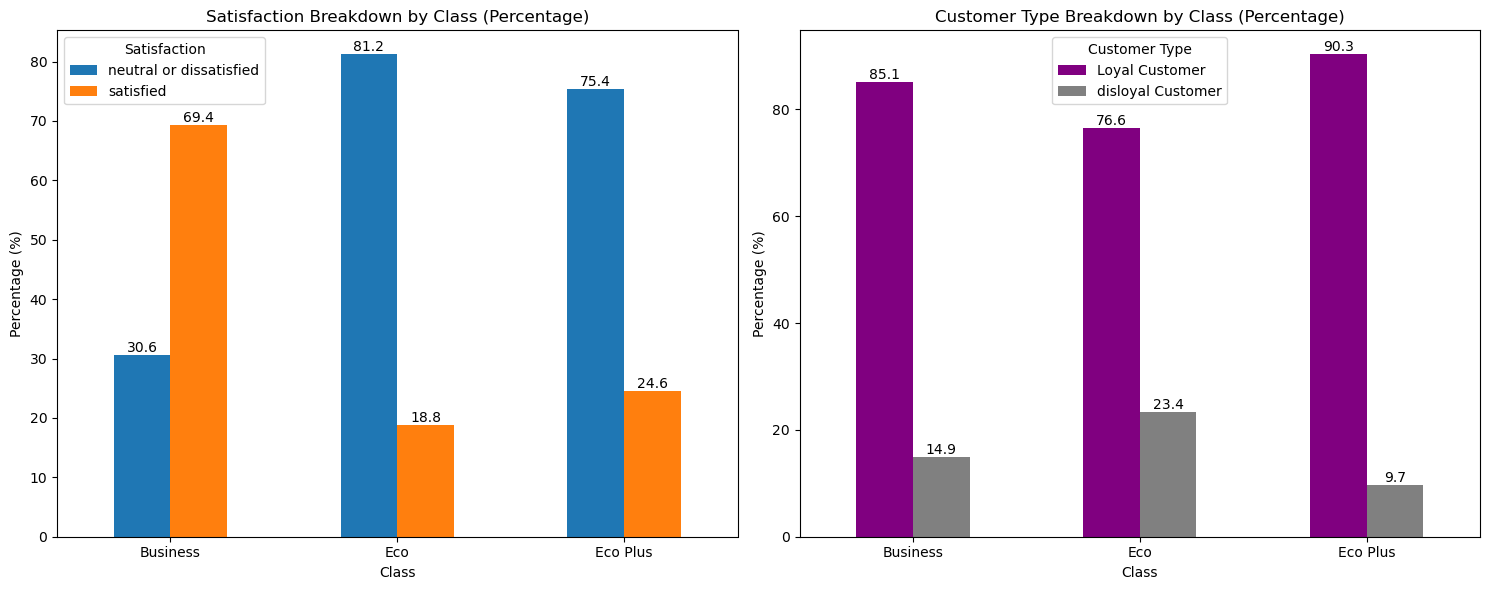

In [57]:
# Plot Satisfaction Breakdown by Class
satisfaction_counts = pd.crosstab(df['Class'], df['satisfaction'])
satisfaction_pct = (pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100).round(1)

# Plot Loyalty Breakdown by Class
loyal_counts = pd.crosstab(df['Class'], df['Customer Type'])
loyal_pct = (pd.crosstab(df['Class'], df['Customer Type'], normalize='index') * 100).round(1)


fig, ax = plt.subplots(1, 2, figsize=(15, 6))
satisfaction_pct.plot(kind='bar', ax=ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].bar_label(ax[0].containers[1])
ax[0].set_title('Satisfaction Breakdown by Class (Percentage)')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Percentage (%)')
ax[0].legend(title='Satisfaction')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)


loyal_pct.plot(kind='bar', ax=ax[1], color=['purple', 'grey'])
ax[1].bar_label(ax[1].containers[0])
ax[1].bar_label(ax[1].containers[1])
ax[1].set_title('Customer Type Breakdown by Class (Percentage)')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Percentage (%)')
ax[1].legend(title='Customer Type')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

The data reveals a stark contrast in satisfaction: 69.4% of Business Class passengers are satisfied, compare to just 18.8% seen in Economy. This could be attributed the superior physical comfort of premium cabins. However, satisfaction does not guarantee retention. 

Surprisingly, Business Class passengers show a lower loyalty rate (85.1%) compared to Economy Plus travelers (90.3%). This suggests that physical comfort alone is insufficient to lock in premium customers. If seats and food aren't the primary drivers of retention for this segment, what is?

To answer this, I turned to machine learning to uncover the hidden predictors of passenger satisfaction.

<sup>(Check out [01_cleaning_and_prep.ipynb](../technical_analysis/01_cleaning_and_prep.ipynb) for more details)</sup>

## Expectation Gap

To understand the drivers of satisfaction without human bias, I established a Baseline Random Forest Model with an accurary of 96.2%. 
Unlike linear models, a Random Forest can detect complex, non-linear relationships (e.g., satisfaction might drop off sharply only after a delay exceeds 30 minutes). I fed the model the raw passenger data with demographics, flight details, and survey scores, then asked it to rank features by their predictive power. 

<sup>(Check out [02_baseline_model_discovery.ipynb](../technical_analysis/02_baseline_model_discovery.ipynb) for more details)</sup>

In [58]:
# Load the baseline model
baseline_model_data = pickle.load(open('../models/baseline_model.pkl', 'rb'))
print(f'Baseline Model loaded with an accuracy of {(baseline_model_data['accuracy'] * 100):.1f}%')

Baseline Model loaded with an accuracy of 96.2%


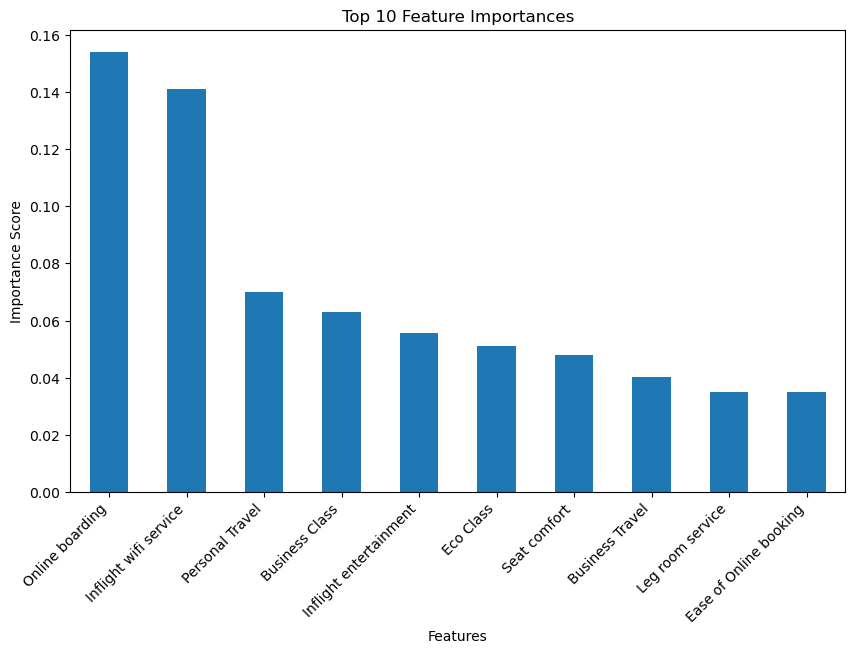

In [ ]:
baseline_importance = pd.DataFrame({'Feature': baseline_model_data['feature_names'], 'Importance': baseline_model_data['importance']}).sort_values(by='Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
baseline_importance.plot.bar(x='Feature', y='Importance', ax=ax)
ax.set_title('Top 10 Feature Importances')
ax.set_xlabel('Features')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend().remove()

plt.show()

Interestingly, the model flagged `Online Boarding` as the #1 predictor of satisfaction, toping `Seat Comfort` (7th) and `Leg Room Service` (9th). 

Why would a 5-minute administrative task matter more than a 6-hour physical experience?

<sup>(Check out [04_final_model_evaluation.ipynb](../technical_analysis/04_final_model_evaluation.ipynb) for more details)</sup>

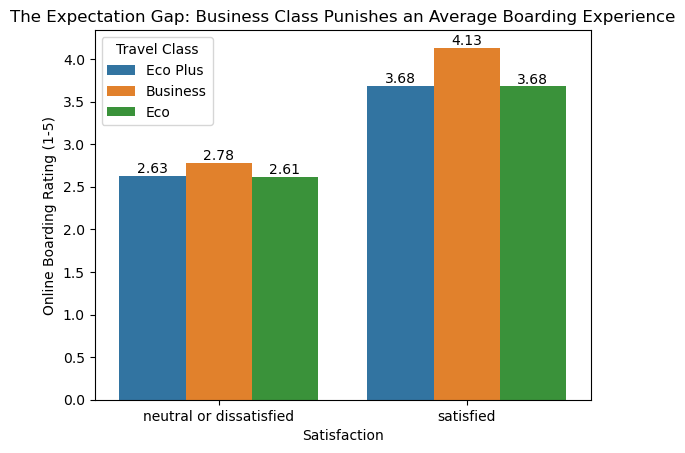

In [64]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='Online boarding', x='satisfaction', hue='Class', ax=ax, errorbar=None)
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.bar_label(ax.containers[1], fmt='%.2f')
ax.bar_label(ax.containers[2], fmt='%.2f')
ax.set_title("The Expectation Gap: Business Class Punishes an Average Boarding Experience")
ax.set_ylabel("Online Boarding Rating (1-5)")
ax.set_xlabel("Satisfaction")
ax.legend(title='Travel Class')
plt.show()

The chart above exposes the mechanism behind the model's finding: The "Digital Handshake"

Economy passengers (Green/Blue bars) remain relatively satisfied even with a "Average" (3/5) boarding experience. On the otherhand, Business Class passengers (Purple bar) have higher expectations. It takes a digital boarding experience of at least a 4/5 to be satisfied.

The data shows that the "Digital Handshake" (App, Check-in, Boarding) may not just be a convenience, but a prerequisit for an enjoyable trip.

## Digital vs Physical Comfort

To transform these findings into interpretable and actionable insights, I engineered a Strategic Model with an accuracy of 93%. I grouped the 14 granular survey metrics into three catergories that represent competing investment priorities:

1. `The Digital Friction`: (Wifi, App Booking, Online Boarding) – Represents IT Infrastructure.

2. `The Physical Comfort`: (Seat Comfort, Legroom, Food) – Represents Hardware Assets.

3. `The Service Logistics`: (Staff, Baggage, On-board Service) – Represents Human Capital.

I also engineered a "Business Retention" interaction feauture to explicitly measure how much the Boarding Experience specifically weighs on premium travelers.

<sup>(Check out [03_feature_engineering.ipynb](../technical_analysis/03_feature_engineering.ipynb) for more details)</sup>

In [61]:
# Load the strategic model
strategic_model_data = pickle.load(open('../models/engineered_model.pkl', 'rb'))
print(f'Strategic Model loaded with an accuracy of {(strategic_model_data['accuracy'] * 100):.1f}%')

Strategic Model loaded with an accuracy of 93.1%


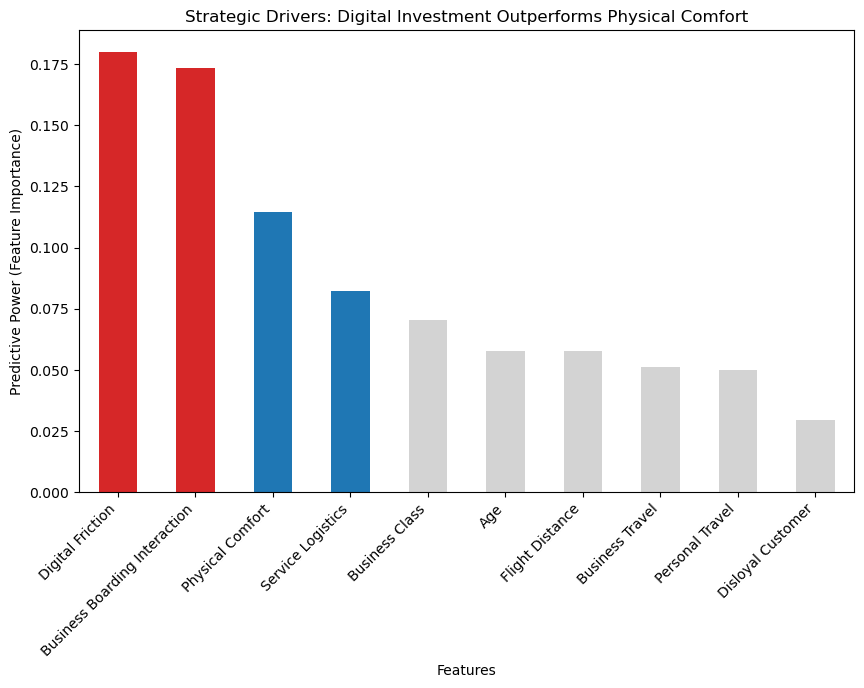

In [62]:
strategic_importance = pd.DataFrame({'Feature': strategic_model_data['feature_names'], 'Importance': strategic_model_data['importance']}).sort_values(by='Importance', ascending=False).head(10)
colors = []
for feat in strategic_importance['Feature']:
    if 'Digital' in feat or 'Int' in feat:
        colors.append('#d62728')  # Red (Strategic Win)
    elif 'Comfort' in feat or 'Service' in feat:
        colors.append('#1f77b4')  # Blue (Traditional View)
    else:
        colors.append('lightgray') # Gray (Context)

fig, ax = plt.subplots(figsize=(10, 6))

strategic_importance.plot.bar(x='Feature', y='Importance', ax=ax, color=colors)
ax.set_title('Strategic Drivers: Digital Investment Outperforms Physical Comfort')
ax.set_xlabel('Features')
ax.set_ylabel('Predictive Power (Feature Importance)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend().remove()

plt.savefig('../images/strategic_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Retraining the model on these strategic pillars shows that `Digital Score`, which represents all levels of passengers is a dominat drivers of customer satisfaction. Additionally, `Business Boarding Interaction` ranking second highlights the importance of the Digital Handshake for Business class passangers. This proves that the "Soft Product" (Software/Connectivity) is now a stronger predictor of retention than the "Hard Product" (Seats). 

<sup>(Check out [04_final_model_evaluation.ipynb](../technical_analysis/04_final_model_evaluation.ipynb) for more details)</sup>

## Customer Validation

The Random Forest model established a correlation digital friction and satisfaction. However, a correlation cannot reveal the mechanism of failure. To understand exactly how the digital experience can fail high-value customers, I validated the model's findings using a Semantic Search (Vector RAG) analysis of recent Reddit discussions in frequent flyer communities (r/delta, r/AmericanAirlines).

<sup>(Check out [05_reddit_validation.ipynb](../technical_analysis/05_reddit_validation.ipynb) for more details)</sup>

The Mechanism of Friction The semantic search did not uncover complaints about "UI design" or "font choices." Instead, it revealed that "Digital Friction" often acts as a hard Revenue Blocker.

The following user accounts serve as qualitative evidence that app failures directly prevent revenue capture (upgrades) and degrade the perceived value of the premium product:
> *"On neither Iberia’s nor AA’s websites and apps can I see business class seats on the seating map. I’d like to know the cost to upgrade."*
- The customer is attempting to purchase a high-margin product, and the digital infrastructure is preventing the transaction.

> *"This afternoon I found out that my upgrade triggered a system glitch that canceled the second leg of my trip."*
- The digital system punished the customer for upgrading, creating a severe detractor event.

> *"My boarding pass only updates SOMETIMES when my seats get upgraded...I get a red light at the gate, and they have to physically print a new BP (boarding pass)."*
- The friction occurs exactly where the Business Class experience is supposed to be seamless (Priority Boarding), dampaning the value of the status they paid for.

#### Conclusion

Though comfort remains important, there is a ceiling. There are diminishing returns for improvements compared to the reduction of digital friction. Retrofitting an entire fleet with new Business Class seats can take years and cost millions per aircraft ([Simple Flying](https://simpleflying.com/aircraft-seats-cost-guide/)). Improving the Digital Handshake (App stability, Boarding integration) is a centralized software update that scales instantly across the entire network.

The model coupled with customer experience suggests that shifting capital expenditure (CapEx) from marginal seat improvements to radical digital overhaul is the most efficient path to securing Business Class loyalty.